# BM-GHSL Surface Match

In [1]:
import pandas as pd
import pycountry_convert as pc

from bokeh.plotting import output_notebook

from conflict_monitoring_ntl.viz import plot_scatter_bokeh, plot_scatter

output_notebook()

Loading BokehJS ...

In [2]:
def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except KeyError:
        pass


def merge_datasets(df: pd.DataFrame) -> pd.DataFrame:
    df["f1"]  = 2 * df.TP / (2 * df.TP + df.FP + df.FN)
    df["precision"] = df.TP / (df.TP + df.FP)
    df["recall"] = df.TP / (df.TP + df.FN)

    df["continent"] = df["country"].apply(country_to_continent)
    df = df[~df.continent.isna()]

    hdi_df = pd.read_csv("data/human_development_index.csv")[["iso3", "hdi_2020"]]
    df = pd.merge(left=df, right=hdi_df, how="left", left_on="gid", right_on="iso3")
    df = df[~df.hdi_2020.isna()].rename(columns={"hdi_2020": "hdi"}).drop(columns="iso3")

    min_size, max_size = 10, 40
    pixel_min = df['pixel_count'].min()
    pixel_max = df['pixel_count'].max()
    df['size'] = ((df['pixel_count'] - pixel_min) / (pixel_max - pixel_min)) * (max_size - min_size) + min_size

    return df

## 1% Threshold

### F1

In [3]:
df = pd.read_parquet("results/global_1_percent_thresh")
df = merge_datasets(df)
plot_scatter_bokeh(df)

### Precision

As shown below, the precision - the proportion of correct predictions among all positive predictions - is roughly the same for both Africa and Europe.

In [4]:
plot_scatter_bokeh(df, y="precision")

### Recall

The difference between Africa and Europe is primarily due to recall: among all positive labels, the proportion of predicted positives is noticeably lower for Africa.

In [5]:
plot_scatter_bokeh(df, y="recall")

## 20% Threshold

### F1

In [6]:
df = pd.read_parquet("results/global_20_percent_thresh")
df = merge_datasets(df)
plot_scatter_bokeh(df)

### Precision

Precision follows roughly the same pattern as the F1 score.

In [7]:
plot_scatter_bokeh(df, y="precision")

### Recall

With a 20% threshold for GHSL Surface, we are able to identify nearly all positive cases in Europe and a substantial proportion in Africa as well.

In [8]:
plot_scatter_bokeh(df, y="recall", legend_loc="bottom_right")

## Final Paper Static Visualization

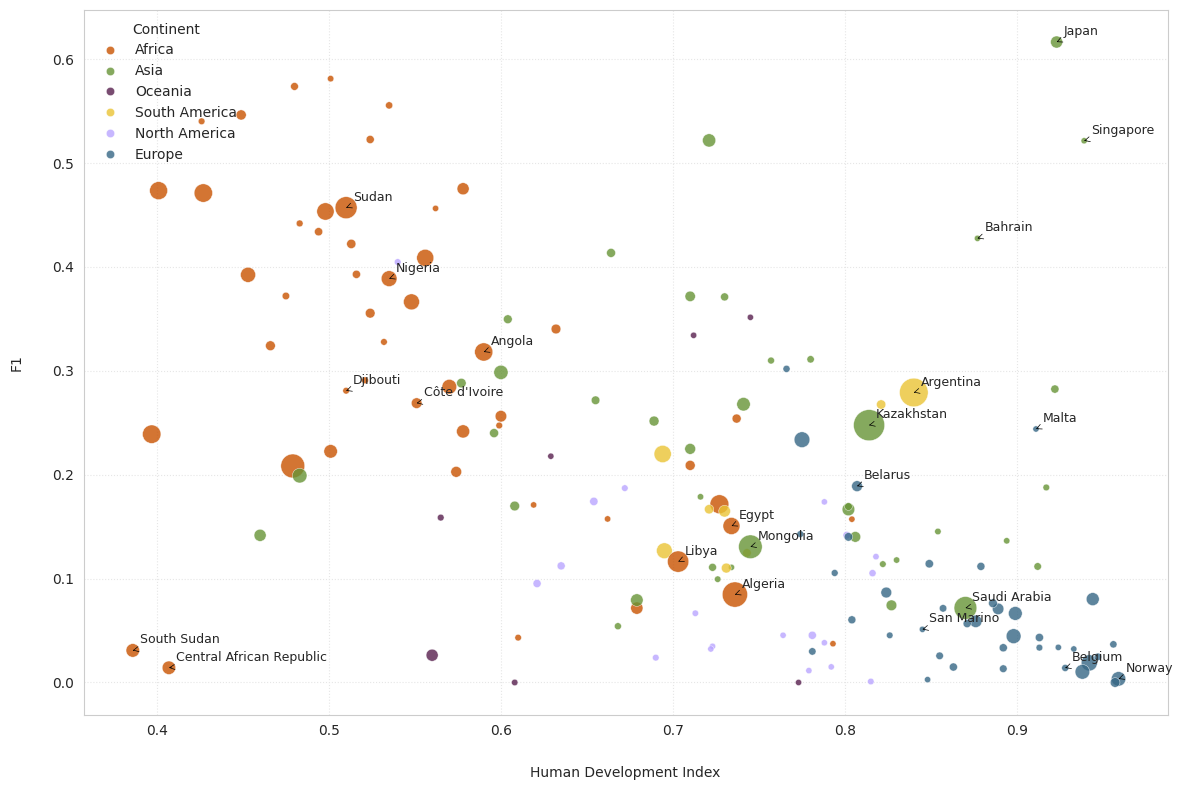

In [9]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Djibouti",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Egypt",
    "Malta",
    "Belarus",
    "Algeria",
    "Norway",
    "Singapore",
    "Belgium",
    "San Marino",
    "Mongolia",
    "Kazakhstan",
    "Saudi Arabia",
    "Argentina",
    "Nigeria",
    "Angola",
    "Japan",
    "Bahrain"
]

plot_scatter(df, countries_to_plot)